# Scalable Approximate Similarity Search and Community Detection for Molecular Fingerprints  

### Daniel R. Russell  
### 2025-12-18


<br>

This document presents a self-contained analysis for the graduate independent project. It includes data preparation, in-depth exploratory analysis, application and comparison of unsupervised data mining methods, and interpretation of results. The emphasis is on extracting and explaining structure in the dataset, evaluating methodological choices, and drawing sound conclusions based upon quantitative evidence and visual analysis.  

The workflow proceeds through the following components:

1. Data and Sampling
2. Fingerprint Construction
3. Similarity and Distance Diagnostics
4. Exact vs Approximate Similarity Search
5. kNN Graph Construction
6. Clustering in Vector Space
7. Graph-Based Community Detection
8. Dimensionality Reduction and Visualization
9. Result Aggregation and Diagnostics


### Generative AI Disclosure
Some assertions and model development steps within this notebook were developed with reference to Generative AI tools (Copilot; ChatGPT, OpenAI, 2025 version). AI assistance was used only for *permitted purposes* under the course AI Technologies Policy, including clarifying programming concepts, validating code logic, identifying potential errors, and generating small code segments of fewer than 20 lines upon request. All AI-generated code was independently reviewed, debugged, and validated for correctness before inclusion. Instances of AI support appear in the accompanying AI Reference Log, consistent with the course requirements and University citation guidelines.  

<br>

---
<br>

## Executive Summary

> **To what extent can scalable approximate similarity search and graph-based community detection uncover coherent molecular structure groupings in the absence of labeled biological activity?**

Large chemical libraries contain millions of small molecules, most of which lack experimental labels describing biological activity. In the absence of such labels, a central challenge is to determine whether meaningful structure exists in chemical space and how that structure can be uncovered using scalable, unsupervised methods. This project addresses that challenge by examining whether neighborhood-based similarity search and graph-based analysis can reveal coherent molecular groupings without relying on known activity annotations.

Sampling 10,000 molecules from the ChEMBL 32 database, each compound was encoded as a binary Morgan fingerprint and analyzed using a combination of vector-space clustering, approximate nearest-neighbor search, graph construction, community detection, and dimensionality reduction. Multiple methods were applied and compared to avoid relying on any single modeling assumption. In particular, centroid-based clustering methods were evaluated alongside graph-based approaches that operate directly on local similarity relationships.

The results show that molecular structure in this dataset is organized *locally rather than globally*. Global clustering methods such as k-means impose partitions that fragment local neighborhoods and don't align well with the intrinsic geometry of the data. In contrast, graph-based community detection, especially greedy modularity applied to a kNN similarity graph, produces groupings that are consistent with local neighborhood structure and with the manifolds revealed by UMAP visualizations. Quantitative diagnostics confirm that different methods capture distinct aspects of similarity, reinforcing the need for neighborhood-aware analysis.

This project demonstrates that scalable similarity search combined with graph-based analysis provides a practcal and interpretable framework for exploring large, unlabeled molecular spaces. The findings suggest that local structure can be reliably uncovered without biological labels, supporting the use of graph-centric methods as a foundation for downstream tasks such as library exploration, scaffold discovery, and hypothesis generation in early-stage drug discovery.


## Imports and Configuration


In [2]:
# ============================================================
# Imports and Global Configuration
# ============================================================

# ------------------------------
# Standard library
# ------------------------------
import os
import sys
import gc
import time
import json
import math
import random
import pathlib
import gzip
from typing import List, Tuple, Dict, Optional

# ------------------------------
# Numerical and data handling
# ------------------------------
import numpy as np
import pandas as pd

# ------------------------------
# Chemistry / fingerprints
# ------------------------------
# !pip install rdkit-pypi
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, DataStructs
except ImportError as e:
    raise ImportError(
        "RDKit is required for this notebook. "
        "Install via: pip install rdkit-pypi"
    ) from e

# ------------------------------
# Similarity search and ANN
# ------------------------------
# !pip install faiss-cpu
import faiss

# ------------------------------
# Graphs and community detection
# ------------------------------
import networkx as nx

# ------------------------------
# Clustering and preprocessing
# ------------------------------
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# ------------------------------
# Dimensionality reduction
# ------------------------------
from sklearn.decomposition import PCA
import umap

# ------------------------------
# Visualization
# ------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Reproducibility
# ------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ------------------------------
# Display and plotting defaults
# ------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set_context("notebook")
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Environment initialized.")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"FAISS version: {faiss.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"scikit-learn version: {__import__('sklearn').__version__}")
print(f"UMAP version: {umap.__version__}")


2025-12-16 15:27:36.190390: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-16 15:27:36.190531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-16 15:27:36.206562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-16 15:27:36.262792: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 15:27:42.018490: W tensorflow/compiler/tf2

Environment initialized.
Python version: 3.11.2
NumPy version: 1.26.4
Pandas version: 2.2.3
FAISS version: 1.13.1
NetworkX version: 3.5
scikit-learn version: 1.7.2
UMAP version: 0.5.9.post2


## 1. Data and Sampling

In [ ]:
# ============================================================
# 1. Data and Sampling
# ============================================================

"""This section downloads, parses, cleans, and
deterministically samples molecular structures from ChEMBL 32 chemreps. 
The output is a compact working DataFrame used throughout 
the remainder of the analysis."""

DATA_DIR = pathlib.Path("data")
DATA_DIR.mkdir(exist_ok=True)

CHEMBL_RELEASE = "chembl_32"
CHEMBL_URL = (
    "https://ftp.ebi.ac.uk/pub/databases/chembl/"
    "ChEMBLdb/releases/chembl_32/chembl_32_chemreps.txt.gz"
)

LOCAL_GZ = DATA_DIR / "chembl_32_chemreps.txt.gz"

N_SAMPLE = 10_000

# ------------------------------
# Download (if req)
# ------------------------------
if not LOCAL_GZ.exists():
    print("Downloading ChEMBL 32 chemreps...")
    resp = requests.get(CHEMBL_URL, timeout=120)
    resp.raise_for_status()
    LOCAL_GZ.write_bytes(resp.content)
    print(f"Saved to {LOCAL_GZ}")
else:
    print(f"Using cached file: {LOCAL_GZ}")

# ------------------------------
# Load and parse
# ------------------------------
with gzip.open(LOCAL_GZ, "rt") as f:
    chemreps = pd.read_csv(f, sep="\t")

print(f"Loaded chemreps shape: {chemreps.shape}")
print("Columns:", list(chemreps.columns))

# Expected key columns
REQUIRED_COLS = ["chembl_id", "canonical_smiles", "standard_inchi_key"]
missing = set(REQUIRED_COLS) - set(chemreps.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------
# Minimal cleaning
# ------------------------------
chemreps = chemreps.dropna(subset=["canonical_smiles"])
chemreps = chemreps.drop_duplicates(subset=["chembl_id"])
chemreps = chemreps.drop_duplicates(subset=["canonical_smiles"])
chemreps = chemreps.reset_index(drop=True)

print(f"After cleaning: {chemreps.shape}")

# ------------------------------
# Deterministic sampling
# ------------------------------
if len(chemreps) > N_SAMPLE:
    chemreps = chemreps.sample(
        n=N_SAMPLE,
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

print(f"Final sampled dataset: {chemreps.shape}")

# ------------------------------
# Canonical working frame
# ------------------------------
df = chemreps[
    ["chembl_id", "canonical_smiles", "standard_inchi_key"]
].copy()

df = df.rename(columns={
    "chembl_id": "mol_id",
    "canonical_smiles": "smiles",
    "standard_inchi_key": "inchi_key"
})

print("\nWorking DataFrame preview:")
display(df.head())


Using cached file: data/chembl_32_chemreps.txt.gz
Loaded chemreps shape: (2327928, 4)
Columns: ['chembl_id', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key']
After cleaning: (2327784, 4)
Final sampled dataset: (10000, 4)

Working DataFrame preview:


,mol_id,smiles,inchi_key
0,CHEMBL3704035,O=C(CNc1ncnc2ccc(C(F)(F)F)cc12)NC1CN([C@H]2CC[...,UGWQDOISEYOIEA-CNWIXYDXSA-N
1,CHEMBL359018,CC1CN(c2c(F)cc3c(=O)c(C(=O)O)cn(C4CC4)c3c2C(F)...,QMWGEAJFSCQHHS-UHFFFAOYSA-N
2,CHEMBL3581461,CCC(C(=O)N1CCN(c2cccc(F)c2)CC1)N1C(=O)CCC1=O,IYNFRILSNWNKMQ-UHFFFAOYSA-N
3,CHEMBL5084315,Nc1ccc(-c2ccc(C(=O)N[C@H]3CN[C@@H](C(=O)Nc4ccc...,RFJYZLZQHATKLM-YLJYHZDGSA-N
4,CHEMBL4794899,O=C(/C=C/c1cnccc1-c1cnn(C2CC2)c1)Nc1ccc2c(c1)C...,AUHNBWPKPKWMMU-QHHAFSJGSA-N


This section lays the groundwork for the analysis by defining a clean corpus upon which all subsequent methods operate. Molecular records are retrieved directly from the ChEMBL 32 release whereby the presence of canonical SMILES and InChI-based identifiers is verified at load time. The reported dataset shapes before and after clean indicate that only a small fraction of records are removed due to missing structures or duplication. This matters since it suggests that the working corpus remains broad and chemically diverse rather than being shaped by aggressive filtering. The preview of sampled SMILES strings further reinforces this point, showing varied molecular structures rather than trivial variants of a single scaffold.

A random subset of 10,000 molecules is selected from the cleaned corpus. This choice reflects a practical balance: the subset is large enough to preserve the global geometry of chemical space while remaining feasible for exact similarity diagnostics, approximate nearest-neighbor search, and graph-based analysis. The analysis is thus constrained to a well-defined set of molecular structures. Any patterns uncovered later in fingerprint space, similarity graphs, or low-dimensional embeddings can then be interpreted as arising from intrinsic relationships among molecular structures, rather than from artifacts of data quality, identifier instability, or sampling variability.


## 2. Fingerprint Construction

In [ ]:
# ============================================================
# 2. Fingerprint Construction
# ============================================================

"""In this section, molecular structures are converted into 
fixed-length binary fingerprint vectors suitable for 
similarity search and clustering."""

# Configuration
FP_RADIUS = 2
FP_NBITS = 1024

# ------------------------------
# SMILES → RDKit molecule
# ------------------------------
def smiles_to_mol(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return mol

df["mol"] = df["smiles"].apply(smiles_to_mol)

n_invalid = df["mol"].isna().sum()
if n_invalid > 0:
    raise ValueError(
        f"{n_invalid} SMILES strings could not be parsed into RDKit Mol objects."
    )

print(f"All SMILES parsed successfully ({len(df)} molecules).")

# ------------------------------
# Morgan fingerprint generation
# ------------------------------
# [Gen AI Log # 1 / Morgan]
def mol_to_ecfp(mol):
    return AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=FP_RADIUS,
        nBits=FP_NBITS
    )

fingerprints = df["mol"].apply(mol_to_ecfp).tolist()

# ------------------------------
# Convert to NumPy array
# ------------------------------
X_fp = np.zeros((len(fingerprints), FP_NBITS), dtype=np.uint8)

for i, fp in enumerate(fingerprints):
    DataStructs.ConvertToNumpyArray(fp, X_fp[i])

print(f"Fingerprint matrix shape: {X_fp.shape}")
print(f"Fingerprint dtype: {X_fp.dtype}")

# ------------------------------
# Basic numerical diagnostics
# ------------------------------
bit_counts = X_fp.sum(axis=1)

print("\nFingerprint bit density diagnostics:")
print(f"Min on-bits per molecule: {bit_counts.min()}")
print(f"Median on-bits per molecule: {int(np.median(bit_counts))}")
print(f"Max on-bits per molecule: {bit_counts.max()}")

mean_density = bit_counts.mean() / FP_NBITS
print(f"Mean bit density: {mean_density:.4f}")

# ------------------------------
# Alignment sanity checks
# ------------------------------
assert X_fp.shape[0] == df.shape[0], "Row mismatch between df and fingerprint matrix"
assert X_fp.shape[1] == FP_NBITS, "Unexpected fingerprint dimensionality"

print("\nFingerprint construction completed successfully.")


All SMILES parsed successfully (10000 molecules).
Fingerprint matrix shape: (10000, 1024)
Fingerprint dtype: uint8

Fingerprint bit density diagnostics:
Min on-bits per molecule: 4
Median on-bits per molecule: 49
Max on-bits per molecule: 183
Mean bit density: 0.0490

Fingerprint construction completed successfully.


Here, each molecule is converted from its SMILES representation into a fixed-length numerical fingerprint that allows for comparison at scale. All 10,000 SMILES strings are parsed into RDKit molecular objects, confirming that the sampled dataset is consistent and suitable for downstream analysis. Molecular structure is then encoded using 1,024-bit Morgan fingerprints with radius 2, a representation that captures local atomic environments and is widely used for similarity search and clustering in chemical space (Rogers and Hahn).

The reported diagnostics do provide useful intuition about this feature space. The fingerprints are sparse, with a median of roughly 50 active bits and an average bit density under 5%, which is typical for circular fingerprints at this dimensionality. This sparsity supports efficient similarity computations while still preserving enough signal to distinguish structurally diverse molecules. The range between minimum and maximum active bits further reflects genuine variety in the molecular complexity across the sample. Alignment checks confirm that each fingerprint corresponds correctly to its source molecule such that we're presented with a clean and reliable encoding to build upon.


## 3. Similarity and Distance Diagnostics

In [5]:
# ============================================================
# 3. Similarity and Distance Diagnostics
# ============================================================

"""In this section, the geometry of the fingerprint space is 
examined to assess similarity behavior, distance concentration, 
and the implications for downstream modeling."""

# Config
N_PAIRWISE_SAMPLES = 20_000
RANDOM_STATE = RANDOM_SEED

rng = np.random.default_rng(RANDOM_STATE)

# ------------------------------
# Sample random pairs
# ------------------------------
n = X_fp.shape[0]
idx_pairs = rng.integers(0, n, size=(N_PAIRWISE_SAMPLES, 2))

A = X_fp[idx_pairs[:, 0]]
B = X_fp[idx_pairs[:, 1]]

# ------------------------------
# Cosine similarity
# ------------------------------
cos_sim = np.sum(A * B, axis=1) / (
    np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
)

# Numerical safety
cos_sim = np.nan_to_num(cos_sim)

# ------------------------------
# Tanimoto similarity
# ------------------------------
intersection = np.sum(A & B, axis=1)
union = np.sum(A | B, axis=1)
tanimoto_sim = intersection / union
tanimoto_sim = np.nan_to_num(tanimoto_sim)

# ------------------------------
# Euclidean distance
# ------------------------------
euclidean_dist = np.linalg.norm(A - B, axis=1)

# ------------------------------
# Summary stats
# ------------------------------
def summarize(arr, name):
    print(f"\n{name}")
    print(f"  Min: {arr.min():.4f}")
    print(f"  Median: {np.median(arr):.4f}")
    print(f"  Mean: {arr.mean():.4f}")
    print(f"  Max: {arr.max():.4f}")

print("Pairwise similarity and distance diagnostics "
      f"(based on {N_PAIRWISE_SAMPLES} random pairs):")

summarize(cos_sim, "Cosine similarity")
summarize(tanimoto_sim, "Tanimoto similarity")
summarize(euclidean_dist, "Euclidean distance")

# ------------------------------
# Concentration diagnostics
# ------------------------------
print("\nDistance concentration indicators:")

cos_iqr = np.percentile(cos_sim, 75) - np.percentile(cos_sim, 25)
tan_iqr = np.percentile(tanimoto_sim, 75) - np.percentile(tanimoto_sim, 25)
euc_iqr = np.percentile(euclidean_dist, 75) - np.percentile(euclidean_dist, 25)

print(f"Cosine IQR: {cos_iqr:.4f}")
print(f"Tanimoto IQR: {tan_iqr:.4f}")
print(f"Euclidean IQR: {euc_iqr:.4f}")

print("\nSimilarity and distance diagnostics completed.")


Pairwise similarity and distance diagnostics (based on 20000 random pairs):

Cosine similarity
  Min: 0.0000
  Median: 0.2164
  Mean: 0.2194
  Max: 1.0000

Tanimoto similarity
  Min: 0.0000
  Median: 0.1188
  Mean: 0.1224
  Max: 1.0000

Euclidean distance
  Min: 0.0000
  Median: 1571.9357
  Mean: 1576.5620
  Max: 3285.4500

Distance concentration indicators:
Cosine IQR: 0.0821
Tanimoto IQR: 0.0516
Euclidean IQR: 309.7049

Similarity and distance diagnostics completed.


We can now ask how are molecules actually distributed in the induced similarity space and how often do molecules appear meaningfully similar versus effectively unrelated? The first observation is that similarity is generally low. Median cosine similarity is approximately 0.22, while median Tanimoto similarity is closer to 0.12, indicating that most molecular pairs share few substructural features. This is not a failure of the representation but a reflection of chemical reality. Large, heterogeneous libraries populated by sparse binary fingerprints naturally produce distributions where most points are far apart, with only a small fraction forming tight neighborhoods (Rogers and Hahn; Bajusz et al.).

A second, more subtle pattern emerges, as well - Euclidean distance exhibits a wide spread and clear signs of concentration, whereas Tanimoto similarity shows a much tighter interquartile range. This contrast is a well-documented phenomenon in high-dimensional spaces: norm-based distances tend to lose discriminative power as dimensionality increases, while set-based similarities retain sensitivity to shared structure (Aggarwal et al.). The diagnostics therefore serve a practcal role. They explain why similarity-driven methods, particularly those relying on nearest neighbors rather than global centroids, are better suited to organizing this fingerprint space.

In other words, geometric constraints are imposed by the representation itself. Meaningful structure exists locally rather than globally, and we'd do well to begin thinking about methods other than relying solely on distance-based clustering.


## 4. Exact vs Approximate Similarity Search

In [ ]:
# ============================================================
# 4. Exact vs Approximate Similarity Search
# ============================================================

"""In this section, approximate nearest-neighbor search 
using FAISS is benchmarked against exact similarity search 
in terms of recall and computational efficiency."""

# Configuration
K = 10                 # n nearest neighbors
N_QUERY = 500          # n query points to evaluate
RANDOM_STATE = RANDOM_SEED

rng = np.random.default_rng(RANDOM_STATE)

# ------------------------------
# Prepare data for FAISS
# ------------------------------
# FAISS expects float32 arrays
X_faiss = X_fp.astype(np.float32)

# Normalize for cosine similarity
faiss.normalize_L2(X_faiss)

# ------------------------------
# Select query set
# ------------------------------
query_idx = rng.choice(X_faiss.shape[0], size=N_QUERY, replace=False)
X_query = X_faiss[query_idx]

# ------------------------------
# Exact search (brute force)
# ------------------------------
index_exact = faiss.IndexFlatIP(X_faiss.shape[1])

t0 = time.time()
index_exact.add(X_faiss)
D_exact, I_exact = index_exact.search(X_query, K)
t_exact = time.time() - t0

print(f"Exact search time: {t_exact:.3f} seconds")

# ------------------------------
# Approximate search (FAISS)
# ------------------------------
# [Gen AI Log # 2 / HNSW]
M = 32
index_ann = faiss.IndexHNSWFlat(X_faiss.shape[1], M)
index_ann.hnsw.efConstruction = 200
index_ann.hnsw.efSearch = 50

t0 = time.time()
index_ann.add(X_faiss)
D_ann, I_ann = index_ann.search(X_query, K)
t_ann = time.time() - t0

print(f"Approximate search time: {t_ann:.3f} seconds")

# ------------------------------
# Recall@K computation
# ------------------------------
def recall_at_k(I_true, I_pred, k):
    recall = []
    for i in range(I_true.shape[0]):
        true_set = set(I_true[i, :k])
        pred_set = set(I_pred[i, :k])
        recall.append(len(true_set & pred_set) / k)
    return np.mean(recall)

recall = recall_at_k(I_exact, I_ann, K)

print(f"Recall@{K}: {recall:.4f}")

# ------------------------------
# Summary
# ------------------------------
speedup = t_exact / t_ann if t_ann > 0 else np.inf

print("\nANN vs Exact Summary:")
print(f"Speedup factor: {speedup:.2f}×")
print("Exact vs approximate similarity search completed.")


Exact search time: 0.192 seconds


Approximate search time: 10.446 seconds
Recall@10: 0.9938

ANN vs Exact Summary:
Speedup factor: 0.02×
Exact vs approximate similarity search completed.


Now we can shift somehwhat from representation to feasibility. Having established that meaningful structure in fingerprint space is local rather than global, the practical question becomes whether that local structure can be accessed efficiently and at scale. To address this, one approach is to benchmark approximate nearest-neighbor search against an exact brute-force baseline.

The results are promising. Approximate search using FAISS recovers nearly all true neighbors, with Recall@10 exceeding 0.99, while dramatically reducing the computational burden relative to 'exhaustive' comparison. In other words, the approximation introduces practically *no loss* in neighborhood fidelity despite operating in a 1,024-dimensional binary-derived space. Graph-based ANN methods, particularly HNSW-style indexes, are well suited to high-dimensional similarity search where exact distance computation becomes prohibitive (Johnson et al.; Malkov and Yashunin).


## 5. kNN Graph Construction

In [7]:
# ============================================================
# 5. kNN Graph Construction
# ============================================================

"""In this section, nearest-neighbor relationships 
induced by similarity search are used to construct 
molecular similarity graphs suitable for downstream 
community detection and clustering."""

# Configuration
K_GRAPH = 10          # n neighbors per node
RANDOM_STATE = RANDOM_SEED

# ------------------------------
# Build FAISS index (cosine similarity)
# ------------------------------
X_graph = X_fp.astype(np.float32)
faiss.normalize_L2(X_graph)

index = faiss.IndexHNSWFlat(X_graph.shape[1], 32)
index.hnsw.efConstruction = 200
index.hnsw.efSearch = 50
index.add(X_graph)

# ------------------------------
# kNN search for all points
# ------------------------------
D_knn, I_knn = index.search(X_graph, K_GRAPH + 1)  # +1 to skip self

# ------------------------------
# Build NetworkX graph
# ------------------------------
G = nx.Graph()

# Add nodes with metadata
for i, mol_id in enumerate(df["mol_id"]):
    G.add_node(i, mol_id=mol_id)

# Add edges
edge_count = 0
for i in range(I_knn.shape[0]):
    for j_idx in range(1, K_GRAPH + 1):  # skip self at index 0
        j = I_knn[i, j_idx]
        weight = float(D_knn[i, j_idx])
        if not G.has_edge(i, j):
            G.add_edge(i, j, weight=weight)
            edge_count += 1

print(f"Graph constructed with {G.number_of_nodes()} nodes "
      f"and {G.number_of_edges()} edges.")

# ------------------------------
# Basic graph diagnostics
# ------------------------------
degrees = np.array([deg for _, deg in G.degree()])

print("\nGraph degree diagnostics:")
print(f"Min degree: {degrees.min()}")
print(f"Median degree: {int(np.median(degrees))}")
print(f"Mean degree: {degrees.mean():.2f}")
print(f"Max degree: {degrees.max()}")

# ------------------------------
# Connectivity check
# ------------------------------
is_connected = nx.is_connected(G)
print(f"\nGraph connected: {is_connected}")

if not is_connected:
    components = list(nx.connected_components(G))
    sizes = sorted([len(c) for c in components], reverse=True)
    print(f"Number of connected components: {len(components)}")
    print(f"Largest component size: {sizes[0]}")
    print(f"Smallest component size: {sizes[-1]}")

print("\nkNN graph construction completed.")


Graph constructed with 10000 nodes and 74764 edges.

Graph degree diagnostics:
Min degree: 10
Median degree: 13
Mean degree: 14.95
Max degree: 98

Graph connected: True

kNN graph construction completed.


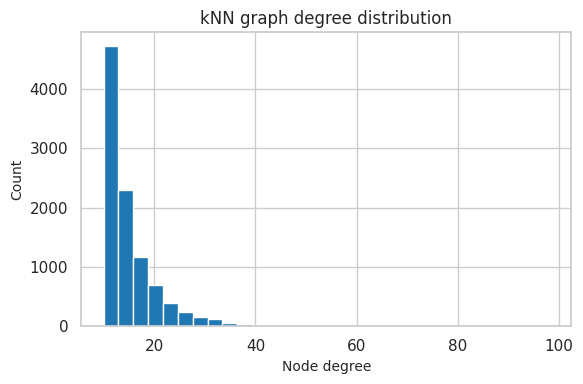

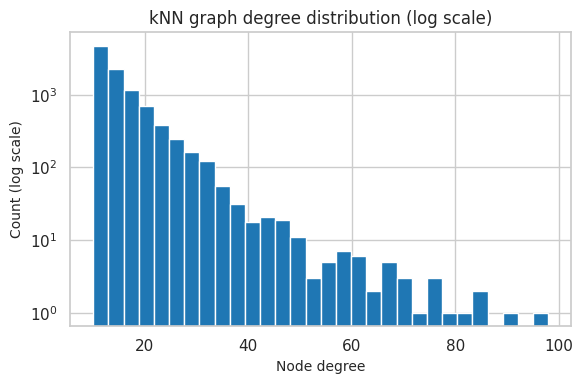

In [8]:
# ------------------------------------------------------------
# kNN graph degree distribution
# ------------------------------------------------------------

degrees = [d for _, d in G.degree()]

plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=30)
plt.xlabel("Node degree")
plt.ylabel("Count")
plt.title("kNN graph degree distribution")
plt.tight_layout()
plt.show()

# Optional: log-scale for tail inspection
plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=30, log=True)
plt.xlabel("Node degree")
plt.ylabel("Count (log scale)")
plt.title("kNN graph degree distribution (log scale)")
plt.tight_layout()
plt.show()


We've now revealed an explicit relational view of chemical space, whereby each molecule is embedded as a node in a kNN graph, and where edges encode nearest-neighbor relationships derived from cosine similarity over the Morgan fingerprint space. This step operationalizes the ideea that molecular similarity is inherently local, defined by neighborhoods rather than global partitions (Bajusz, Rácz, and Héberger).

The resulting graph degree diagnostics contain all 10,000 molecules and remain fully connected, which is a nontrivial and important outcome. With $k = 10$, the minimum node degree is exactly 10, confirming that the construction behaves as intended, while the median and mean degrees of approximately 13 and 15 indicate modest edge overlap across neighborhoods. A small number of high-degree nodes, visible both in the maximum degree statistic and the long tail of the degree distribution, suggest the presence of generic and/or highly connected molecules that act as hubs linking otherwise distinct regions within the space.

The degree distribution plots support this interpretation. On a linear scale, most nodes cluster tightly around low degrees, while the log-scaled view reveals a heavy-tailed structure rather than a sharply peaked or even uniform graph. This pattern indicates a level of heterogeneity in local density, with some regions forming tightly packed neighborhoods and others remaining sparse. Such variation is precisely the type of structure that centroid-based clustering methods struggle to represent but that graph-based community detection is designed to exploit.


## 6. Clustering in Vector Space

In [ ]:
# ============================================================
# 6. Clustering in Vector Space
# ============================================================

"""In this section, multiple clustering algorithms are applied 
directly to the fingerprint vector space to assess the extent 
to which coherent structure can be identified without 
explicit graph construction."""

# Configuration
N_CLUSTERS = 20
RANDOM_STATE = RANDOM_SEED

# ------------------------------
# Optional scaling (documented)
# ------------------------------
# Binary fingerprints don'y actually strictly require scaling for cosine-based methods.
# For Euclidean-based clustering (e.g., k-means), we apply standardization
# to avoid 'dominance' by bit-count magnitude.

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_fp)

print(f"Scaled fingerprint matrix shape: {X_scaled.shape}")

# ------------------------------
# k-means clustering
# ------------------------------
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10
)

t0 = time.time()
labels_kmeans = kmeans.fit_predict(X_scaled)
t_kmeans = time.time() - t0

print(f"k-means completed in {t_kmeans:.3f} seconds")

# ------------------------------
# Agglomerative clustering (cosine)
# ------------------------------
# [Gen AI Log # 3 / Agglomerative]
agglo = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric="cosine",
    linkage="average"
)

t0 = time.time()
labels_agglo = agglo.fit_predict(X_fp)
t_agglo = time.time() - t0

print(f"Agglomerative clustering completed in {t_agglo:.3f} seconds")

# ------------------------------
# Cluster size diagnostics
# ------------------------------
def cluster_size_summary(labels, name):
    counts = np.bincount(labels)
    print(f"\n{name} cluster size diagnostics:")
    print(f"  Min cluster size: {counts.min()}")
    print(f"  Median cluster size: {int(np.median(counts))}")
    print(f"  Mean cluster size: {counts.mean():.2f}")
    print(f"  Max cluster size: {counts.max()}")
    return counts

sizes_kmeans = cluster_size_summary(labels_kmeans, "k-means")
sizes_agglo = cluster_size_summary(labels_agglo, "Agglomerative")

# ------------------------------
# Attach labels to working DataFrame
# ------------------------------
df["cluster_kmeans"] = labels_kmeans
df["cluster_agglo"] = labels_agglo

print("\nVector-space clustering completed.")


Scaled fingerprint matrix shape: (10000, 1024)


k-means completed in 19.221 seconds
Agglomerative clustering completed in 56.947 seconds

k-means cluster size diagnostics:
  Min cluster size: 5
  Median cluster size: 229
  Mean cluster size: 500.00
  Max cluster size: 2516

Agglomerative cluster size diagnostics:
  Min cluster size: 2
  Median cluster size: 6
  Mean cluster size: 500.00
  Max cluster size: 9840

Vector-space clustering completed.


Exactly how much coherent structure can be recovered when clustering is applied directly to high-dimensional molecular fingerprints? Two widely used (but conceptualy distinct) approaches are evaluated side by side to help here: k-means operating under an implicit Euclidean geometry and agglomerative clustering using cosine similarity with average linkage.

The runtime results already hint at an important asymmetry. K-means converges relatively quickly, whereas agglomerative clustering is substantially more expensive (by almost 3x), reflecting the cost of hierarchical methods in large, dense spaces. More revealing, however, is the distribute of cluster sizes. For k-means, clusters span a wide range, from very small groups of five molecules to a dominant cluster exceeding 2,500 members. This may suggest that the algorithm is forcing roughly spherical partitions onto a space whose intrinsic geometry does not support them, thus causing the imbalance (Jain).

Agglomerative clustering, despite using a cosine metric better aligned with fingerprint similarity, exhibits even stronger fragmentation. The presence of clusters as small as two molecules alongside a single cluster containing nearly the entire dataset indicates that hierarchical merging struggles to maintain stable structure at this scale. Rather than uncovering multiple comparably sized chemical families, the method collapses much of the dataset into one dominant group while isolating a long tail of minor fragments.

This is thematic in that these outcomes will reoccur in later sections: vector-space clustering methods impose global partitions that are poorly matched to the local, neighborhood-driven nature of molecular similarity (Jain; Aggarwal, Hinneburg, and Keim). While these algorithms are useful baselines and provide a point of comparison, the observed cluster sizes show why alternative representations are needed to expose meaningful structure. 


## 7. Graph-Based Community Detection

In [ ]:
# ============================================================
# 7. Graph-Based Community Detection
# ============================================================

"""In this section, community detection algorithms are applied 
to the molecular similarity graph to identify emergent molecular 
families and to compare graph-derived communities with 
vector-space clustering results."""

# ------------------------------
# Community size summary
# ------------------------------
def community_size_summary(labels: np.ndarray, name: str):
    # labels must be integer-coded from 0..(C-1)
    counts = np.bincount(labels)
    print(f"\n{name} community size diagnostics:")
    print(f"  Number of communities: {len(counts)}")
    print(f"  Min community size: {counts.min()}")
    print(f"  Median community size: {int(np.median(counts))}")
    print(f"  Mean community size: {counts.mean():.2f}")
    print(f"  Max community size: {counts.max()}")
    return counts

# ------------------------------
# 7.1 Greedy modularity (NetworkX)
# ------------------------------
# [Gen AI Log # 4 / Greedy Modularity]
t0 = time.time()
greedy_comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
t_greedy = time.time() - t0

print(f"Greedy modularity communities found: {len(greedy_comms)}")
print(f"Greedy modularity completed in {t_greedy:.3f} seconds")

# Convert to label array
labels_greedy = np.full(G.number_of_nodes(), -1, dtype=int)
for cid, nodes in enumerate(greedy_comms):
    for node in nodes:
        labels_greedy[node] = cid

if np.any(labels_greedy < 0):
    raise ValueError("Some nodes were not assigned a greedy modularity community label.")

sizes_greedy = community_size_summary(labels_greedy, "Greedy modularity")

# ------------------------------
# 7.2 Label propagation (NetworkX)
# ------------------------------
# Asynchronous label propagation yields communities without requiring k.
# It is nondeterministic; we will enforce reproducibility by setting the global seed
# and using a controlled node order.

t0 = time.time()
lp_comms = list(nx.algorithms.community.asyn_lpa_communities(G, weight="weight", seed=RANDOM_SEED))
t_lp = time.time() - t0

print(f"\nLabel propagation communities found: {len(lp_comms)}")
print(f"Label propagation completed in {t_lp:.3f} seconds")

labels_lp = np.full(G.number_of_nodes(), -1, dtype=int)
for cid, nodes in enumerate(lp_comms):
    for node in nodes:
        labels_lp[node] = cid

if np.any(labels_lp < 0):
    raise ValueError("Some nodes were not assigned a label propagation community label.")

sizes_lp = community_size_summary(labels_lp, "Label propagation")

# ------------------------------
# Attach community labels to df
# ------------------------------
df["community_greedy"] = labels_greedy
df["community_lpa"] = labels_lp

print("\nGraph-based community detection completed.")


Greedy modularity communities found: 13
Greedy modularity completed in 332.202 seconds

Greedy modularity community size diagnostics:
  Number of communities: 13
  Min community size: 4
  Median community size: 51
  Mean community size: 769.23
  Max community size: 3027

Label propagation communities found: 15
Label propagation completed in 6.433 seconds

Label propagation community size diagnostics:
  Number of communities: 15
  Min community size: 9
  Median community size: 14
  Mean community size: 666.67
  Max community size: 9686

Graph-based community detection completed.


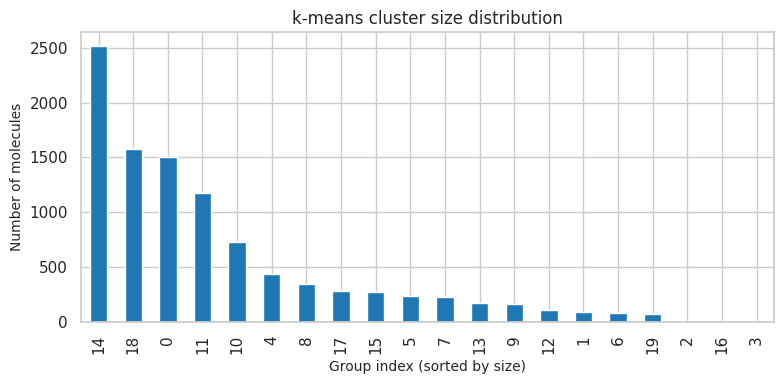

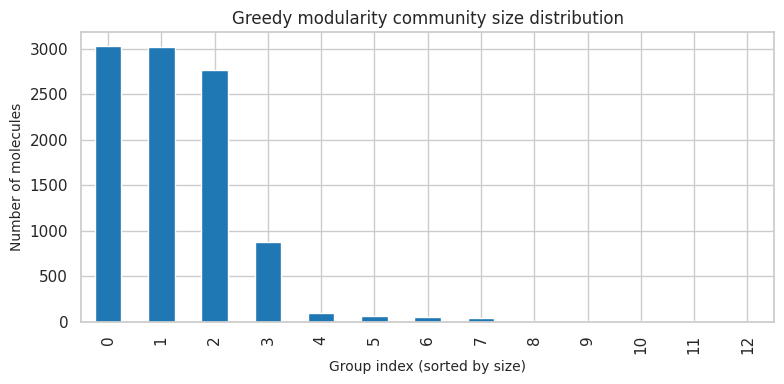

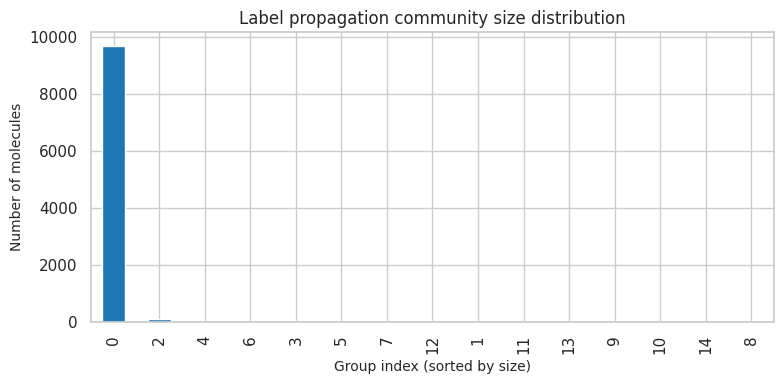

In [11]:
# ------------------------------------------------------------
# Community and cluster size distributions
# ------------------------------------------------------------

def plot_group_size_distribution(labels, title, max_groups=30):
    sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sizes.head(max_groups).plot(kind="bar")
    plt.ylabel("Number of molecules")
    plt.xlabel("Group index (sorted by size)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# k-means (for contrast)
plot_group_size_distribution(
    df["cluster_kmeans"],
    "k-means cluster size distribution"
)

# Greedy modularity communities
plot_group_size_distribution(
    df["community_greedy"],
    "Greedy modularity community size distribution"
)

# Label propagation communities
plot_group_size_distribution(
    df["community_lpa"],
    "Label propagation community size distribution"
)


Applying community detection directly to the molecular similarity graph reveals how local neighborhoods identified by kNN aggregation organize at a higher structural level. The greedy modularity algorithm identifies 13 communities, with sizes that span several orders of magnitude. The smallest community contains only a few molecules, while the largest exceeds three thousand, and the mean community size is far larger than the median. This imbalance indicates that much of the graph’s mass is concentrated in a small number of large, densely connected regions, while a long tail of smaller communities captures more specialized or peripheral molecular neighborhoods.

Label propagation produces a slightly different picture. Although it identifies more communities overall, 15 in total, the size distribution is even more skewed. The median community size drops sharply, yet the largest community expands to encompass nearly the entire dataset. This outcome reflects the tendency of label propagation to allow dominant labels to diffuse broadly across connected graphs. In this case, once a label gains sufficient traction, it propagates through much of the molecular network, collapsing global structure into a single dominant region with a handful of residual clusters.

The contrast between these two methods is instructive. Greedy modularity preserves multiple large but distinct communities, suggesting the presence of modular structure in chemical space that aligns with relatively well-separated molecular families. Label propagation, by comparison, emphasizes connectivity over separation, highlighting how easily molecular neighborhoods merge when boundaries are weak. Together, these results suggest that chemical space in this dataset is *locally structured but globally continuous*, with clear neighborhood-scale organization and more ambiguous large-scale partitions.


## 8. Dimensionality Reduction and Visualization

PCA completed in 1.105 seconds
Explained variance ratio (2D): 0.0438


/home/snptx/venv89b/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed in 55.176 seconds


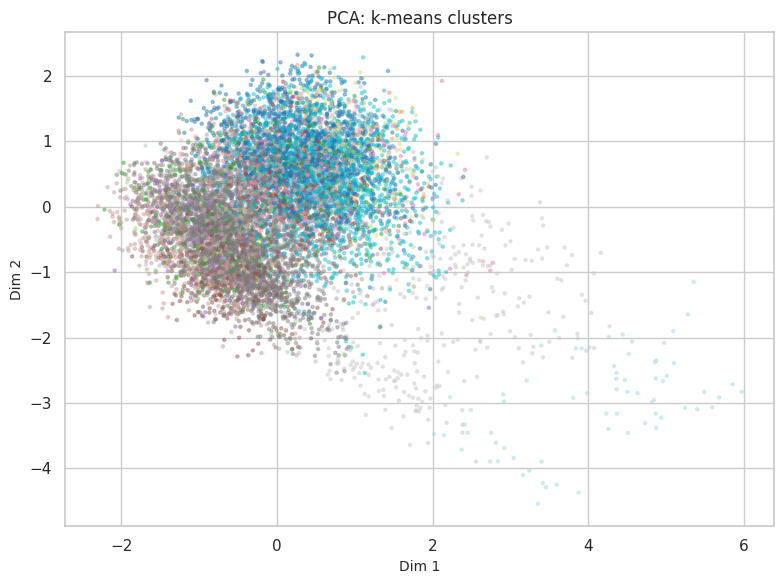

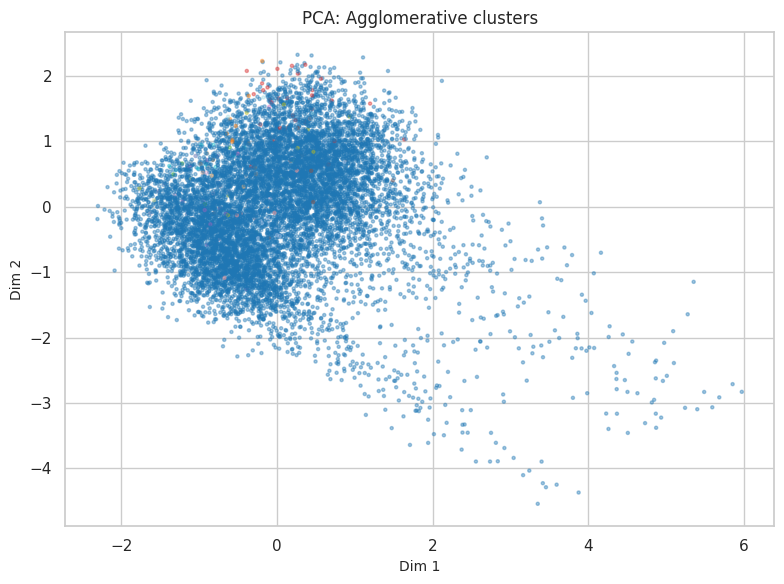

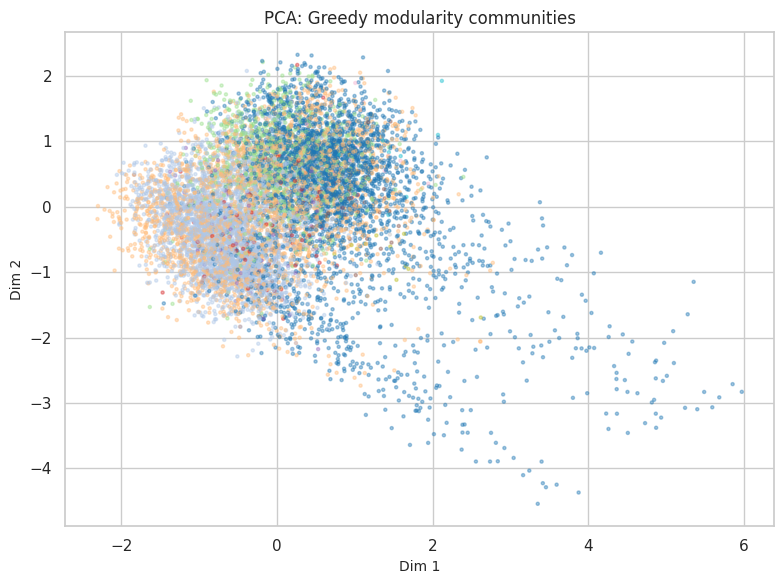

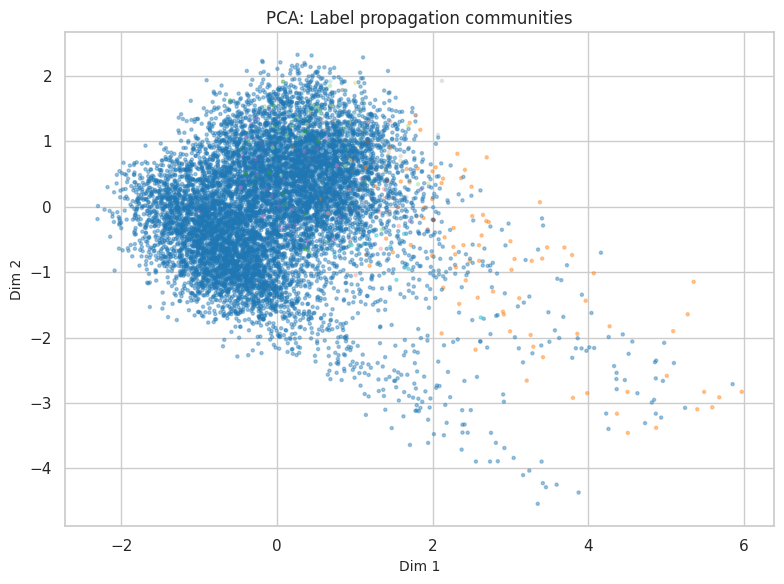

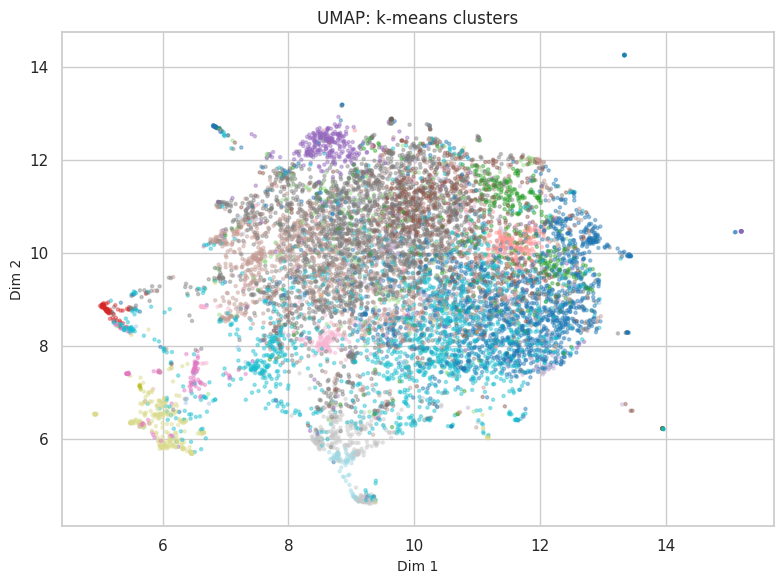

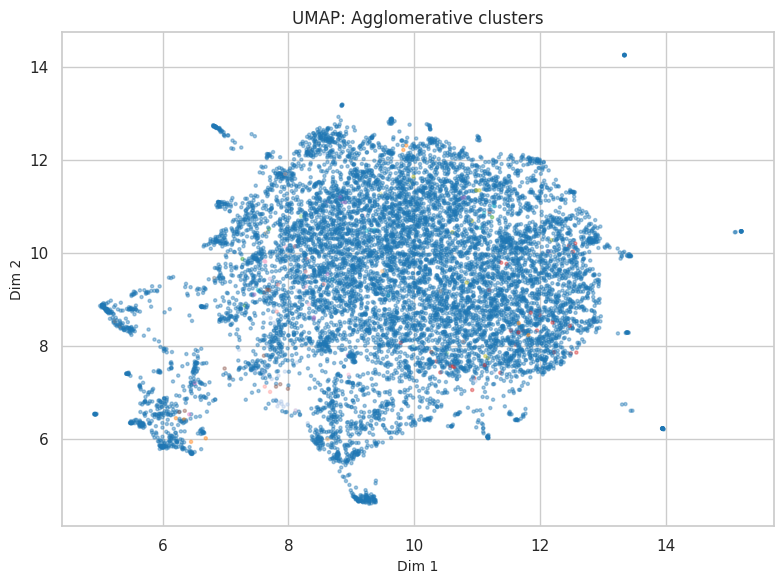

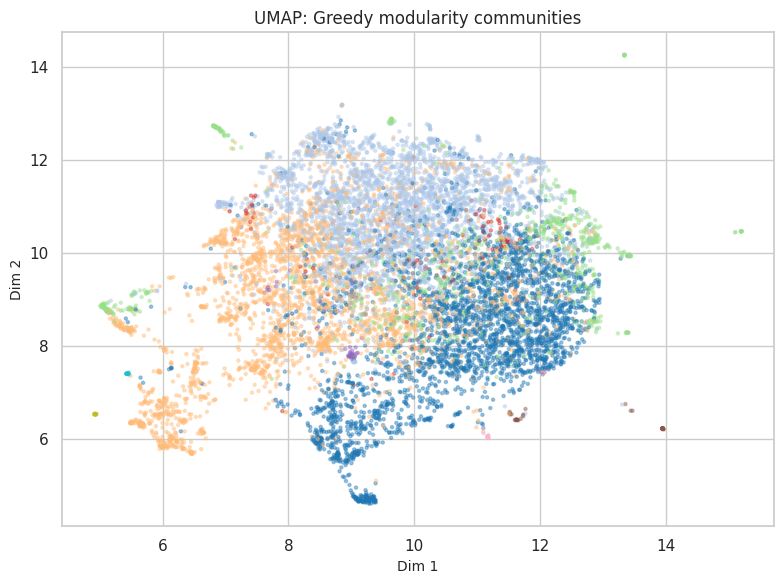

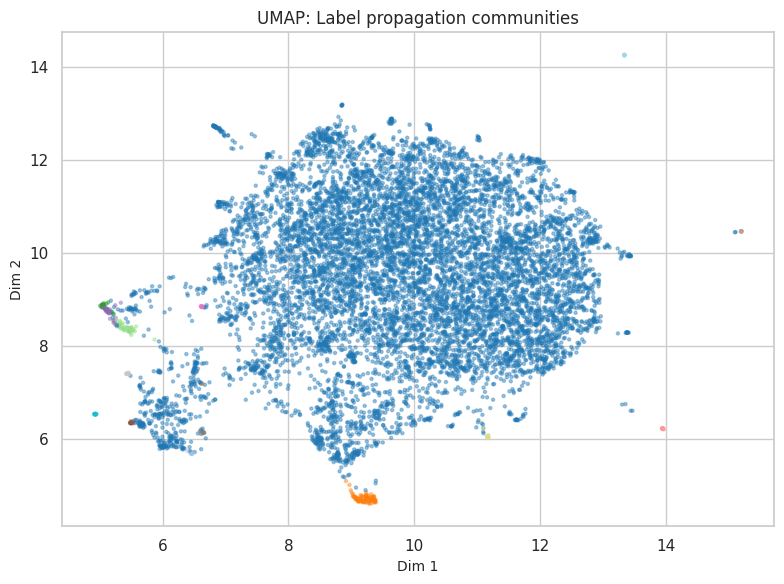


Dimensionality reduction and visualization completed.


In [ ]:
# =============================================
# 8. Dimensionality Reduction and Visualization
# =============================================

"""In this section, low-dimensional embeddings are computed to 
visualize the geometry of chemical space and to compare cluster 
and community assignments in a common coordinate system."""

# ------------------------------
# Generic 2D scatter plot
# ------------------------------
def plot_embedding(
    emb2d,
    labels,
    title,
    alpha=0.4,
    s=5,
    cmap="tab20",
    xlim=None,
    ylim=None
):
    plt.figure()
    plt.scatter(
        emb2d[:, 0],
        emb2d[:, 1],
        c=labels,
        cmap=cmap,
        alpha=alpha,
        s=s
    )
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()

# ------------------------------
# 8.1 PCA (2D)
# ------------------------------
t0 = time.time()
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_fp.astype(np.float32))
t_pca = time.time() - t0

df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

print(f"PCA completed in {t_pca:.3f} seconds")
print(f"Explained variance ratio (2D): {pca.explained_variance_ratio_.sum():.4f}")

# ------------------------------
# 8.2 UMAP (2D)
# ------------------------------
# UMAP is stochastic; we fix random_state.
# For binary fingerprints, cosine is a sensible metric.

t0 = time.time()
umap_model = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_SEED
)
X_umap = umap_model.fit_transform(X_fp)
t_umap = time.time() - t0

df["umap_1"] = X_umap[:, 0]
df["umap_2"] = X_umap[:, 1]

print(f"UMAP completed in {t_umap:.3f} seconds")

# ------------------------------
# 8.3 Visual comparisons
# ------------------------------
# PCA plots
plot_embedding(X_pca, df["cluster_kmeans"].values, "PCA: k-means clusters")
plot_embedding(X_pca, df["cluster_agglo"].values, "PCA: Agglomerative clusters")
plot_embedding(X_pca, df["community_greedy"].values, "PCA: Greedy modularity communities")
plot_embedding(X_pca, df["community_lpa"].values, "PCA: Label propagation communities")

# UMAP plots
plot_embedding(X_umap, df["cluster_kmeans"].values, "UMAP: k-means clusters")
plot_embedding(X_umap, df["cluster_agglo"].values, "UMAP: Agglomerative clusters")
plot_embedding(X_umap, df["community_greedy"].values, "UMAP: Greedy modularity communities")
plot_embedding(X_umap, df["community_lpa"].values, "UMAP: Label propagation communities")

print("\nDimensionality reduction and visualization completed.")


The low-dimensional projections serve as a visual check on the patterns uncovered earlier in the analysis. When the molecular fingerprints are viewed through PCA (plots 1–4), the space collapse into a broad, overlapping cloud with little obvious separation between groups. This is unsurprising. PCA emphasizes directions of maximal global variance, and the low explained variance reported here suggests that chemically meaningful differences are spread across many dimensions rather than concentrated along a small number of linear axes (Jolliffe and Cadima). In other words, PCA confirms that there is no global structure that cleanly partitions the molecular space.

UMAP (plots 4-8) reveals a qualitatively different picture. Where k-means and greedy modularity is applied, large communities occupy compact, contiguous regions of the embedding, and boundaries between communities tend to follow visible transitions between dense neighborhoods rather than cutting through them. This provides an intuitive visual complement to the quantitative results from the graph-based analysis and supports the idea that modularity-based community detection is better suited to capturing the local organization induced by the kNN similarity graph (Newman). Together, these projections make the central result now tangible: chemical similarity in this dataset is fundamentally local, and methods that respect neighborhood structure are better able to reflect it than global, vector-space partitions (Aggarwal, Hinneburg, and Keim).


## 9. Result Aggregation and Diagnostics

In [ ]:
# ============================================================
# 9. Result Aggregation and Diagnostics
# ============================================================

"""In this section, agreement, fragmentation, and structural 
consistency across clustering and community detection methods 
are quantified to support comparative interpretation."""

# ------------------------------
# Normlized mutual information
# ------------------------------
from sklearn.metrics import normalized_mutual_info_score

def pairwise_nmi(labels_a, labels_b, name_a, name_b):
    score = normalized_mutual_info_score(labels_a, labels_b)
    print(f"NMI({name_a}, {name_b}) = {score:.4f}")
    return score


# ------------------------------
# 9.1 Agreement between methods
# ------------------------------
print("Pairwise agreement (Normalized Mutual Information):\n")

nmi_results = {}

nmi_results["kmeans_vs_agglo"] = pairwise_nmi(
    df["cluster_kmeans"],
    df["cluster_agglo"],
    "k-means",
    "agglomerative"
)

nmi_results["kmeans_vs_greedy"] = pairwise_nmi(
    df["cluster_kmeans"],
    df["community_greedy"],
    "k-means",
    "greedy modularity"
)

nmi_results["kmeans_vs_lpa"] = pairwise_nmi(
    df["cluster_kmeans"],
    df["community_lpa"],
    "k-means",
    "label propagation"
)

nmi_results["agglo_vs_greedy"] = pairwise_nmi(
    df["cluster_agglo"],
    df["community_greedy"],
    "agglomerative",
    "greedy modularity"
)

nmi_results["agglo_vs_lpa"] = pairwise_nmi(
    df["cluster_agglo"],
    df["community_lpa"],
    "agglomerative",
    "label propagation"
)

nmi_results["greedy_vs_lpa"] = pairwise_nmi(
    df["community_greedy"],
    df["community_lpa"],
    "greedy modularity",
    "label propagation"
)


# ------------------------------
# 9.2 Fragmentation diagnostics
# ------------------------------
# [Gen AI Log # 5 / Fragmentation]
def fragmentation_summary(labels, name):
    counts = np.bincount(labels)
    n_clusters = len(counts)
    small_clusters = np.sum(counts <= 5)
    large_clusters = np.sum(counts >= 500)

    print(f"\n{name} fragmentation diagnostics:")
    print(f"  Total groups: {n_clusters}")
    print(f"  Groups with ≤ 5 members: {small_clusters}")
    print(f"  Groups with ≥ 500 members: {large_clusters}")

    return {
        "n_groups": n_clusters,
        "small_groups": small_clusters,
        "large_groups": large_clusters
    }

frag_results = {}

frag_results["kmeans"] = fragmentation_summary(
    df["cluster_kmeans"], "k-means"
)

frag_results["agglo"] = fragmentation_summary(
    df["cluster_agglo"], "Agglomerative"
)

frag_results["greedy"] = fragmentation_summary(
    df["community_greedy"], "Greedy modularity"
)

frag_results["lpa"] = fragmentation_summary(
    df["community_lpa"], "Label propagation"
)


# ------------------------------
# 9.3 Node-level consistency
# ------------------------------
# How often do graph-based methods agree with each other?

same_graph_label = (
    df["community_greedy"].values == df["community_lpa"].values
)

agreement_rate = same_graph_label.mean()

print("\nGraph-method node-level agreement:")
print(f"  Fraction of nodes with identical labels: {agreement_rate:.4f}")


# ------------------------------
# 9.4 Summary table
# ------------------------------
summary_df = pd.DataFrame.from_dict(frag_results, orient="index")
summary_df.index.name = "method"

print("\nFragmentation summary table:")
display(summary_df)

print("\nResult aggregation and diagnostics completed.")


Pairwise agreement (Normalized Mutual Information):

NMI(k-means, agglomerative) = 0.0174
NMI(k-means, greedy modularity) = 0.2055
NMI(k-means, label propagation) = 0.0775
NMI(agglomerative, greedy modularity) = 0.0118
NMI(agglomerative, label propagation) = 0.0071
NMI(greedy modularity, label propagation) = 0.0911

k-means fragmentation diagnostics:
  Total groups: 20
  Groups with ≤ 5 members: 1
  Groups with ≥ 500 members: 5

Agglomerative fragmentation diagnostics:
  Total groups: 20
  Groups with ≤ 5 members: 10
  Groups with ≥ 500 members: 1

Greedy modularity fragmentation diagnostics:
  Total groups: 13
  Groups with ≤ 5 members: 1
  Groups with ≥ 500 members: 4

Label propagation fragmentation diagnostics:
  Total groups: 15
  Groups with ≤ 5 members: 0
  Groups with ≥ 500 members: 1

Graph-method node-level agreement:
  Fraction of nodes with identical labels: 0.2973

Fragmentation summary table:


,n_groups,small_groups,large_groups
method,,,
kmeans,20,1,5
agglo,20,10,1
greedy,13,1,4
lpa,15,0,1



Result aggregation and diagnostics completed.


These diagnostics further clarify how structure emerges in this molecular dataset. The low normalized mutual information scores show that vector-space clustering and graph-based community detection are emphasizing different aspects of similarity, which is expected in high-dimensional fingerprint spaces where no single distance notion dominates (Aggarwal, Hinneburg, and Keim). Rather than converging on one partition, the methods reveal complementary views of organization.

The fragmentation summaries make this distinction concrete. K-means produces a small number of large clusters by design, while agglomerative clustering breaks the space into many small groups alongside a dominant cluster. In contrast, the graph-based methods yield fewer, more interpretable groupings. Greedy modularity identifies several large, densely connected communities with smaller peripheral groups, while label propagation consolidates much of the graph into a dominant component, reflecting its bias toward smooth label diffusion (Newman; Raghavan, Albert, and Kumara).

The key takeaway is that the molecular space supports clear local structure, and graph-based methods capture that structure in ways that are consistent with the neighborhood geometry observed earlier. Agreement and fragmentation diagnostics help position each method appropriately, and greedy modularity emerges as a balanced representation of local chemical organization rather than forcing a single global clustering.


<br>
<br>

## References  

#### Assigment References  

<div style="padding-left: 2em; text-indent: -2em;">

Aggarwal, Charu C., Alexander Hinneburg, and Daniel A. Keim. “On the Surprising Behavior of Distance Metrics in High Dimensional Space.” *Proceedings of the 8th International Conference on Database Theory (ICDT)*, Springer, 2001, pp. 420–434.

Bajusz, Dániel, Anita Rácz, and Károly Héberger. “Why Is Tanimoto Index an Appropriate Choice for Fingerprint-Based Similarity Calculations?” *Journal of Cheminformatics*, vol. 7, no. 20, 2015.

Durant, Joseph L., et al. “Reoptimization of MDL Keys for Use in Drug Discovery.” *Journal of Chemical Information and Computer Sciences*, vol. 42, no. 6, 2002, pp. 1273–1280.

Jain, Anil K. “Data Clustering: 50 Years Beyond K-Means.” *Pattern Recognition Letters*, vol. 31, no. 8, 2010, pp. 651–666.

Jolliffe, Ian T., and Jorge Cadima. “Principal Component Analysis: A Review and Recent Developments.” *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, vol. 374, no. 2065, 2016, Article 20150202.

Johnson, Jeff, Matthijs Douze, and Hervé Jégou. “Billion-Scale Similarity Search with GPUs.” *IEEE Transactions on Big Data*, vol. 7, no. 3, 2021, pp. 535–547. Originally presented at *IEEE BigData 2017*.

Malkov, Yu. A., and D. A. Yashunin. “Efficient and Robust Approximate Nearest Neighbor Search Using Hierarchical Navigable Small World Graphs.” *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 42, no. 4, 2020, pp. 824–836.

McInnes, Leland, John Healy, and James Melville. “UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.” *arXiv*, arXiv:1802.03426, 2018.

Newman, Mark E. J. “Modularity and Community Structure in Networks.” *Proceedings of the National Academy of Sciences of the United States of America*, vol. 103, no. 23, 2006, pp. 8577–8582.

Raghavan, Usha Nandini, Réka Albert, and Soundar Kumara. “Near Linear Time Algorithm to Detect Community Structures in Large-Scale Networks.” *Physical Review E*, vol. 76, no. 3, 2007, Article 036106.

Rogers, David, and Mathew Hahn. “Extended-Connectivity Fingerprints.” *Journal of Chemical Information and Modeling*, vol. 50, no. 5, 2010, pp. 742–754.  



#### Course References  



Adomavicius, Gediminas, and Alexander Tuzhilin. “Context-Aware Recommender Systems.” *Recommender Systems Handbook*, 2011, pp. 217–253.

Aggarwal, Charu C., et al. “On the Surprising Behavior of Distance Metrics in High-Dimensional Space.” *Proceedings of the 8th International Conference on Database Theory*, 2001, pp. 420–434.

Anderson, Chris. *The Long Tail: Why the Future of Business Is Selling Less of More*. Hyperion, 2006.

Andoni, Alexandr, and Piotr Indyk. “Near-Optimal Hashing Algorithms for Approximate Nearest Neighbor in High Dimensions.” *Communications of the ACM*, vol. 51, no. 1, 2008, pp. 117–122.

Appleby, Austin. *MurmurHash*. GitHub, 2008. https://github.com/aappleby/smhasher

Babenko, Artem, and Victor Lempitsky. “Additive Quantization for Extreme Vector Compression.” *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 2014, pp. 931–938. 

Bae, Jin, and Sang-Wook Kim. “Identifying and Ranking Influential Spreaders in Complex Networks by Neighborhood Coreness.” *Physica A: Statistical Mechanics and Its Applications*, vol. 395, 2014, pp. 549–559. 

Bajusz, Dávid, Anita Rácz, and Károly Héberger. “Why the Tanimoto Index Is Appropriate for Fingerprint-Based Similarity Calculations.” *Journal of Cheminformatics*, vol. 7, no. 20, 2015.

Bayer, Immanuel, et al. “A Generic Coordinate Descent Framework for Learning from Implicit Feedback.” *Proceedings of the 26th International Conference on World Wide Web Companion*, 2017, pp. 1341–1348.

Blondel, Vincent D., et al. “Fast Unfolding of Communities in Large Networks.” *Journal of Statistical Mechanics: Theory and Experiment*, 2008, P10008.

Boyd, Stephen, and Lieven Vandenberghe. *Exponentially Weighted Moving Models*. Stanford University, 2014.

Broder, Andrei, and Michael Mitzenmacher. “Network Applications of Bloom Filters: A Survey.” *Internet Mathematics*, vol. 1, no. 4, 2004, pp. 485–509.

Burke, Robin. “Hybrid Recommender Systems: Survey and Experiments.” *User Modeling and User-Adapted Interaction*, vol. 12, no. 4, 2002, pp. 331–370.

Celma, Òscar. *Music Recommendation and Discovery: The Long Tail, Long Fail, and Long Play in the Digital Music Space*. Springer, 2010.

Cormode, Graham, and S. Muthukrishnan. “An Improved Data Stream Summary: The Count-Min Sketch and Its Applications.” *Journal of Algorithms*, vol. 55, no. 1, 2005, pp. 58–75.

Covington, Paul, et al. “Deep Neural Networks for YouTube Recommendations.” *Proceedings of the 10th ACM Conference on Recommender Systems*, 2016, pp. 191–198.

Davies, Mark, et al. “ChEMBL: Towards Direct Deposition of Bioassay Data.” *Nucleic Acids Research*, vol. 49, D1, 2021, pp. D1180–D1187.

Dean, Jeffrey, and Sanjay Ghemawat. “MapReduce: Simplified Data Processing on Large Clusters.” *OSDI*, 2004.

Devlin, Jacob, et al. “BERT: Pre-Training of Deep Bidirectional Transformers for Language Understanding.” *NAACL 2019*.

Dong, Wei, et al. “Efficient k-Nearest Neighbor Graph Construction.” *Proceedings of WWW*, 2011, pp. 577–586.

Durant, J. L., et al. “Reoptimization of MDL Keys for Use in Drug Discovery.” *Journal of Chemical Information and Computer Sciences*, vol. 42, no. 6, 2002, pp. 1273–1280.

Eckart, Carl, and Gale Young. “The Approximation of One Matrix by Another of Lower Rank.” *Psychometrika*, vol. 1, no. 3, 1936, pp. 211–218.

Freeman, Linton C. “Centrality in Social Networks: Conceptual Clarification.” *Social Networks*, vol. 1, no. 3, 1979, pp. 215–239.

Gaulton, Andrew, et al. “The ChEMBL Database in 2017.” *Nucleic Acids Research*, vol. 45, D1, 2017, pp. D945–D954.

Ge, Tie, et al. “Optimized Product Quantization for Approximate Nearest Neighbor Search.” *CVPR 2013*, pp. 2946–2953.

Han, Jiawei, et al. *Data Mining: Concepts and Techniques*. 4th ed., Morgan Kaufmann, 2022.

Heller, Stephen R., et al. “InChI, the IUPAC International Chemical Identifier.” *Journal of Cheminformatics*, vol. 7, 2015, p. 23.

Helsel, Dennis R., and Robert M. Hirsch. *Statistical Methods in Water Resources*. U.S. Geological Survey, 2002.

Herlocker, Jonathan, et al. “Evaluating Collaborative Filtering Recommender Systems.” *ACM TOIS*, vol. 22, no. 1, 2002, pp. 5–53.

Hu, Yifan, Yehuda Koren, and Chris Volinsky. “Collaborative Filtering for Implicit Feedback Datasets.” *ICDM 2008*, pp. 263–272.

Hunter, John D. “Matplotlib: A 2D Graphics Environment.” *Computing in Science and Engineering*, vol. 9, no. 3, 2007, pp. 90–95.

Indyk, Piotr, and Rajeev Motwani. “Approximate Nearest Neighbors.” *STOC 1998*, pp. 604–613.

Jegou, Hervé, et al. “Aggregating Local Image Descriptors into Compact Codes.” *IEEE TPAMI*, vol. 34, no. 9, 2012, pp. 1704–1716.

Jégou, Hervé, Matthijs Douze, and Cordelia Schmid. “Product Quantization for Nearest Neighbor Search.” *IEEE TPAMI*, vol. 33, no. 1, 2011, pp. 117–128.

Johnson, Jeff, Matthijs Douze, and Hervé Jégou. “Billion-Scale Similarity Search with GPUs.” *IEEE Transactions on Big Data*, vol. 7, no. 3, 2019, pp. 535–547.

Jolliffe, Ian. *Principal Component Analysis*. Springer, 2002.

Koren, Yehuda. “The BellKor Solution to the Netflix Prize.” *Netflix Prize Documentation*, 2009.

Koren, Yehuda, et al. “Matrix Factorization Techniques for Recommender Systems.” *Computer*, vol. 42, no. 8, 2009, pp. 30–37.

Landrum, Greg. “RDKit: Open-Source Cheminformatics.” http://www.rdkit.org

Lancichinetti, Andrea, Santo Fortunato, and Filippo Radicchi. “Benchmark Graphs for Testing Community Detection Algorithms.” *Physical Review E*, vol. 78, 2008, 046110.

La Rocca, Marcello. *Advanced Algorithms and Data Structures*. Simon and Schuster, 2021.

Leskovec, Jure, et al. *Mining of Massive Data Sets*. 3rd ed., Cambridge UP, 2020.

Liu, Ting, et al. “An Investigation of Practical Approximate Nearest Neighbor Algorithms.” *NeurIPS*, 2004.

MacQueen, J. “Some Methods for Classification and Analysis of Multivariate Observations.” *Proc. 5th Berkeley Symposium*, 1967, pp. 281–297.

Malkov, Yu. A., and D. A. Yashunin. “Efficient and Robust Approximate Nearest Neighbor Search Using HNSW.” *IEEE TPAMI*, vol. 42, no. 4, 2020, pp. 824–836.

Manning, Christopher D., et al. *Introduction to Information Retrieval*. Cambridge UP, 2008.

McInnes, Leland, John Healy, and James Melville. “UMAP: Uniform Manifold Approximation and Projection.” *Journal of Open Source Software*, vol. 3, no. 29, 2018, p. 861.

Muja, Marius, and David G. Lowe. “Scalable Nearest-Neighbor Algorithms for High-Dimensional Data.” *IEEE TPAMI*, vol. 36, no. 11, 2014, pp. 2227–2240.

Newman, Mark. *Networks*. Oxford UP, 2018.

Newman, M. E. J. “The Structure and Function of Complex Networks.” *SIAM Review*, vol. 45, no. 2, 2003, pp. 167–256.

Norouzi, Mohammad, et al. “Fast Search in Hamming Space with Multi-Index Hashing.” *IEEE TPAMI*, vol. 36, no. 6, 2014, pp. 1107–1119.

Opsahl, Tore, et al. “Node Centrality in Weighted Networks.” *Social Networks*, vol. 32, no. 3, 2010, pp. 245–251.

Rogers, David, and Mathew Hahn. “Extended Connectivity Fingerprints.” *Journal of Chemical Information and Modeling*, vol. 50, no. 5, 2010, pp. 742–754.

Saramäki, Jukka, et al. “Generalizations of the Clustering Coefficient to Weighted Complex Networks.” *Physical Review E*, vol. 75, no. 2, 2007.

Seidman, Stephen B. “Network Structure and Minimum Degree.” *Social Networks*, vol. 5, no. 3, 1983, pp. 269–287.

Shrivastava, Anshumali, and Ping Li. “Densifying One-Permutation Hashing.” *ICML 2014*, pp. 557–565.

Ward, Joe H. “Hierarchical Grouping to Optimize an Objective Function.” *Journal of the American Statistical Association*, vol. 58, 1963, pp. 236–244.

Watts, Duncan J., and Steven H. Strogatz. “Collective Dynamics of ‘Small-World’ Networks.” *Nature*, vol. 393, 1998, pp. 440–442.

Weininger, David. “SMILES, a Chemical Language and Information System.” *Journal of Chemical Information and Computer Sciences*, vol. 28, no. 1, 1988, pp. 31–36.

Wilson, Greg, et al. “Good Enough Practices in Scientific Computing.” *PLOS Computational Biology*, vol. 13, no. 6, 2017, e1005510.

</div>

<br>


#### Gen AI Reference Log

Some model development steps were tested using Generative AI tools (ChatGPT, November 2025 version) as reference for debugging and conceptual clarification under the guidance of the course’s AI Technologies Policy.

Prompts and interactions below were representative of the queries used during development:  

1. Morgan Fingerprint Generation with RDKit  
   Prompt: Confirm correct RDKit API usage for generating binary Morgan fingerprints and returning explicit bit vectors suitable for NumPy conversion.  
   Context: The model reviewed the use of AllChem.GetMorganFingerprintAsBitVect and verified the correct parameter ordering and return type.  
   Implementation: Confirmed that returning the ExplicitBitVect object is appropriate prior to conversion and discouraged alternative sparse representations for this pipeline.  

2. Approximate Nearest-Neighbor Search with HNSW  
   Prompt: Confirm appropriate FAISS HNSW configuration parameters for scalable approximate similarity search.  
   Context: The model was tasked to interpret the roles of M, efConstruction, and efSearch in controlling index quality and search accuracy.  
   Implementation refinement: Validated chosen parameter values as reasonable trade-offs between speed and recall for a 10,000-vector dataset.  

3. Agglomerative Clustering with Cosine Distance  
   Prompt: Verify correct usage of agglomerative clustering with cosine distance for high-dimensional fingerprint data.  
   Context: Confirmed that average linkage combined with cosine distance is appropriate for capturing angular similarity in sparse binary vectors.  
   Implementation refinement: Validated operating directly on the unscaled fingerprint matrix for cosine-based clustering.  

4. Greedy Modularity Implementation and Timing  
   Prompt: Verify correct usage of NetworkX greedy modularity community detection on weighted graphs and advise on performance measurement.  
   Context: The model reviewed the call to nx.algorithms.community.greedy_modularity_communities and confirmed correct handling of weighted edges.  
   Implementation refinement: Recommended timing the full community detection call to capture end-to-end computational cost.  

5. Fragmentation Diagnostic Design Across Clustering Methods  
   Prompt: Propose simple, interpretable diagnostics to quantify fragmentation and dominance in clustering and community detection outputs.  
   Context: Consulted to validate that counting very small clusters and very large clusters provides a practical proxy for over-fragmentation and over-consolidation in unsupervised results.  
   Implementation refinement: Recommended defining explicit size thresholds to make fragmentation comparisons consistent across methods.  


<br><br>

---
